Hello Owen

Hello it is Matthieu

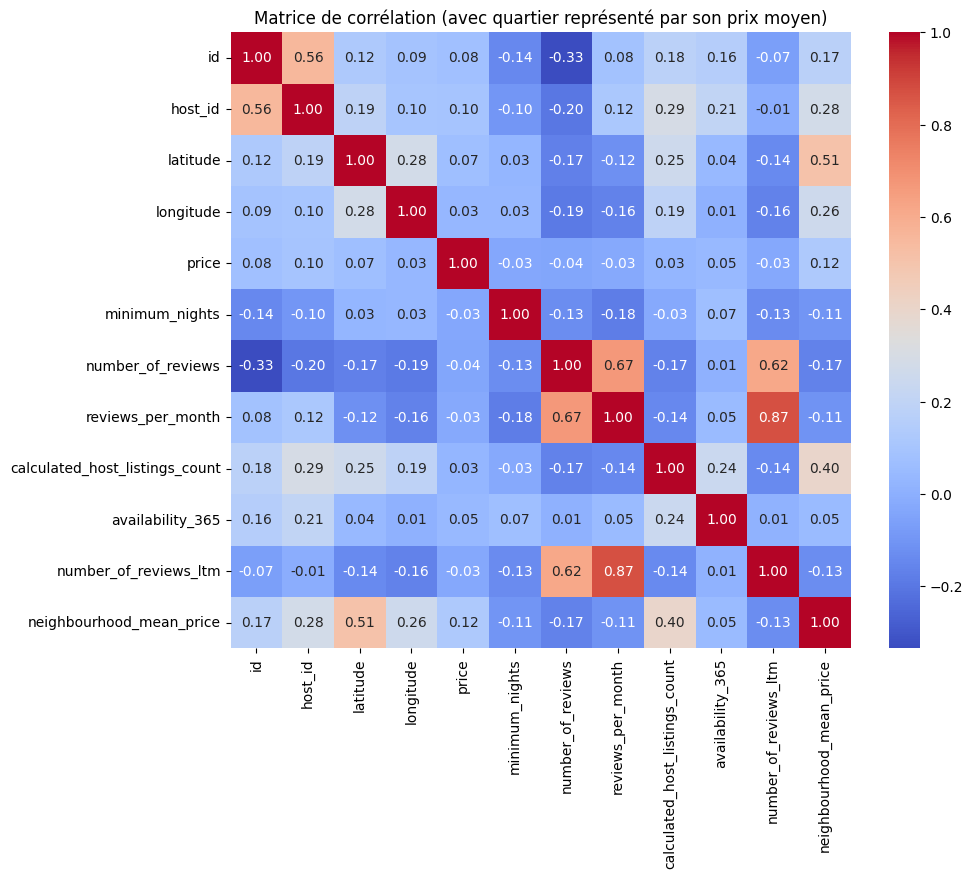

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("listings.csv")

# Supprimer la colonne 'neighbourhood_group' si elle ne contient pas de données
if 'neighbourhood_group' in df.columns:
    if df['neighbourhood_group'].isna().all() or (df['neighbourhood_group'] == '').all():
        df = df.drop(columns=['neighbourhood_group'])

# Créer une variable numérique pour le quartier = prix moyen du quartier
mean_price_per_neigh = df.groupby('neighbourhood')['price'].mean()
df['neighbourhood_mean_price'] = df['neighbourhood'].map(mean_price_per_neigh)

# Calculer la matrice de corrélation
corr = df.select_dtypes(include='number').corr()

# Visualiser
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matrice de corrélation (avec quartier représenté par son prix moyen)")
plt.show()



C:\Users\matth\AppData\Local\Temp\ipykernel_21804\87373830.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10.values, y=top10.index, palette='coolwarm')


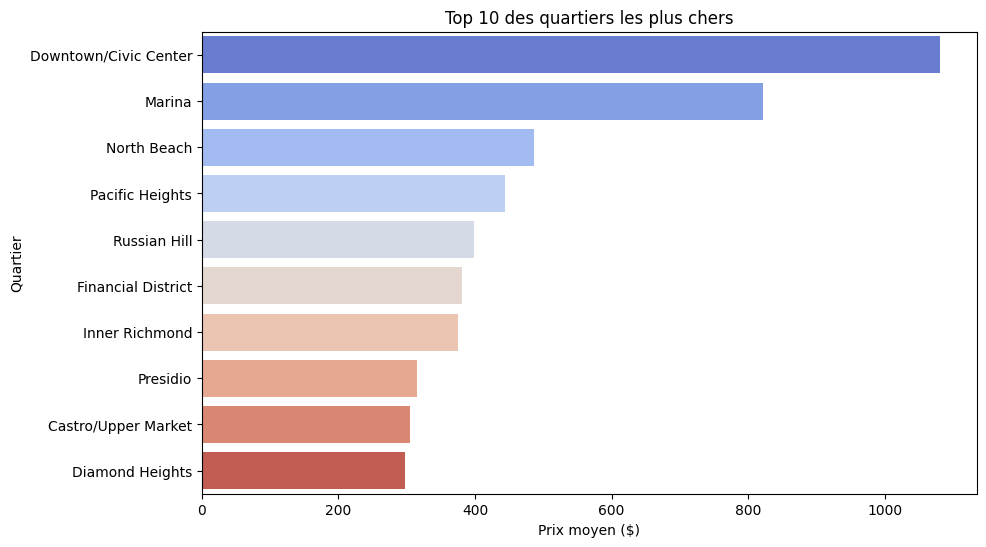

In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Charger le CSV
df = pd.read_csv("listings.csv")

# Supprimer la colonne vide 'neighbourhood_group'
if 'neighbourhood_group' in df.columns:
    if df['neighbourhood_group'].isna().all() or (df['neighbourhood_group'] == '').all():
        df = df.drop(columns=['neighbourhood_group'])

# Calculer le prix moyen par quartier
mean_price_per_neigh = df.groupby('neighbourhood')['price'].mean().sort_values(ascending=False)

# Sélectionner les 10 quartiers les plus chers
top10 = mean_price_per_neigh.head(10)

# Affichage bar chart
plt.figure(figsize=(10,6))
sns.barplot(x=top10.values, y=top10.index, palette='coolwarm')
plt.title("Top 10 des quartiers les plus chers")
plt.xlabel("Prix moyen ($)")
plt.ylabel("Quartier")
plt.show()


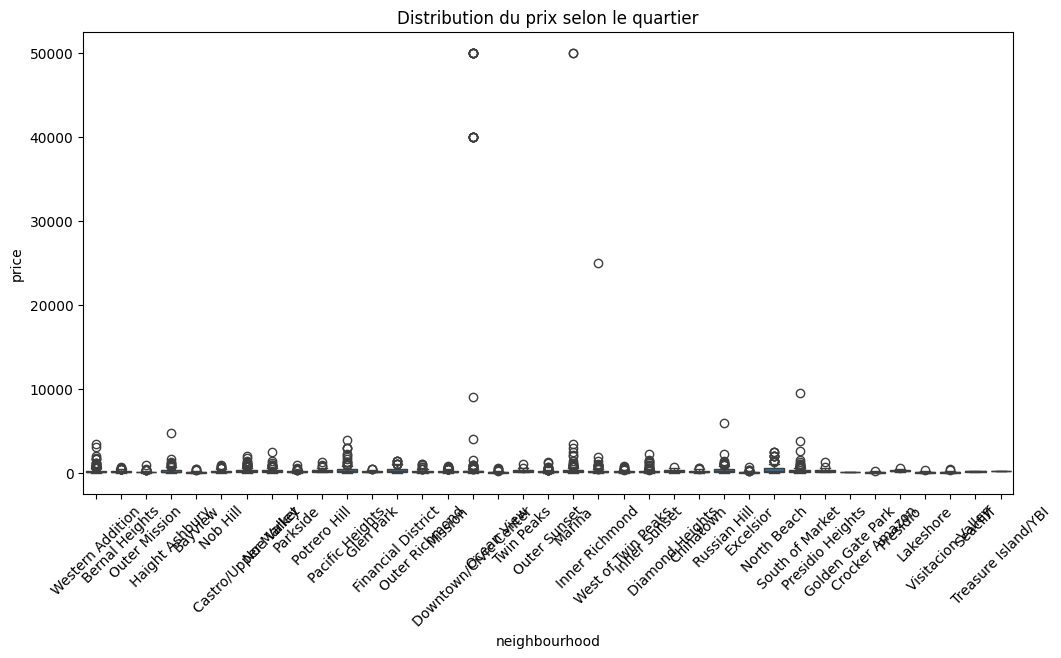

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.boxplot(x='neighbourhood', y='price', data=df)
plt.title('Distribution du prix selon le quartier')
plt.xticks(rotation=45)
plt.show()


C:\Users\matth\AppData\Local\Temp\ipykernel_21804\1112618729.py:15: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.pointplot(
C:\Users\matth\AppData\Local\Temp\ipykernel_21804\1112618729.py:15: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  sns.pointplot(
C:\Users\matth\AppData\Local\Temp\ipykernel_21804\1112618729.py:15: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


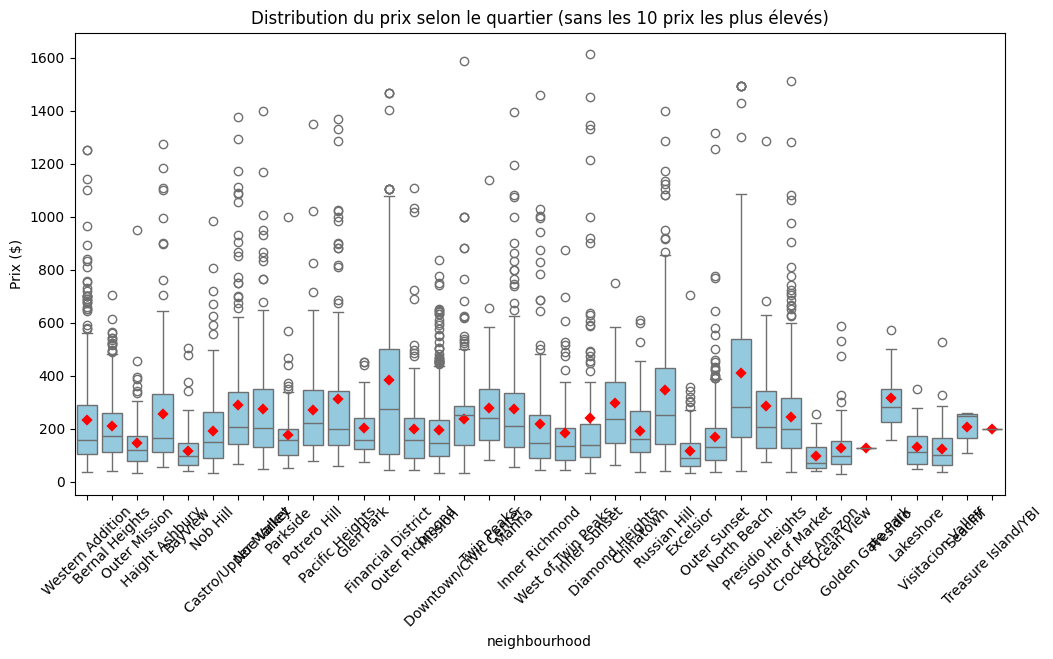

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# Supprimer les 10 prix les plus élevés
#df_filtered = df.sort_values(by='price', ascending=False).iloc[30:]

# Supprime les 1 % des prix les plus élevés
upper_limit = df['price'].quantile(0.99)
df_filtered = df[df['price'] < upper_limit]

plt.figure(figsize=(12, 6))
sns.boxplot(x='neighbourhood', y='price', data=df_filtered, color='skyblue')

# Ajouter la moyenne de chaque quartier en rouge
sns.pointplot(
    x='neighbourhood', y='price', data=df_filtered,
    estimator='mean', color='red', join=False, markers='D', scale=0.8, ci=None
)

plt.title('Distribution du prix selon le quartier (sans les 10 prix les plus élevés)')
plt.xticks(rotation=45)
plt.ylabel('Prix ($)')
plt.show()



Statistique F = 2.5121889736431493
p-value = 1.6138530938096141e-06


C:\Users\matth\AppData\Local\Temp\ipykernel_29544\2202348285.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mean_prices.index, y=mean_prices.values, palette="coolwarm")


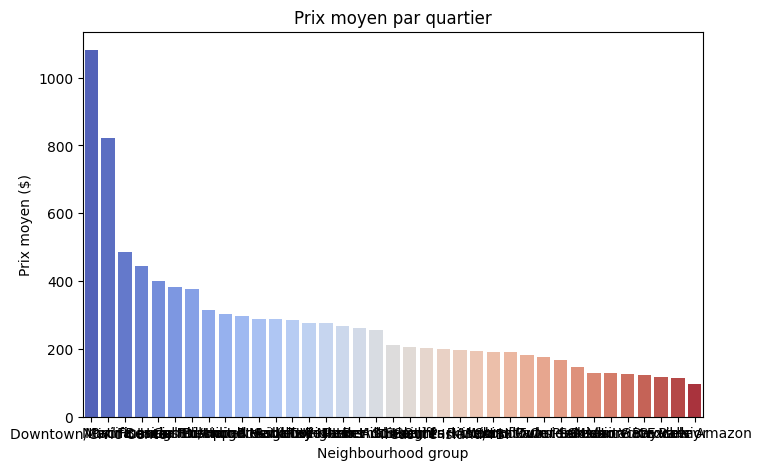

In [25]:
from scipy.stats import f_oneway

groups = [group["price"].dropna().values for name, group in df.groupby("neighbourhood")]
f_stat, p_value = f_oneway(*groups)
print("Statistique F =", f_stat)
print("p-value =", p_value)

mean_prices = df.groupby('neighbourhood')['price'].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=mean_prices.index, y=mean_prices.values, palette="coolwarm")
plt.title('Prix moyen par quartier')
plt.ylabel('Prix moyen ($)')
plt.xlabel('Neighbourhood group')
plt.show()


In [5]:
import pandas as pd
import folium
from folium.plugins import MarkerCluster

# Chargement des données
df = pd.read_csv("listings.csv")  # remplace par ton dataset
df = df.dropna(subset=['latitude', 'longitude', 'price'])

# Nettoyage basique des prix (ex: "$120.00" -> 120)
df['price'] = df['price'].replace('[\$,]', '', regex=True).astype(float)

# Créer la carte centrée sur San Francisco
sf_map = folium.Map(location=[37.77, -122.42], zoom_start=12)

# Option 1 — Si tu veux juste visualiser tous les Airbnb
marker_cluster = MarkerCluster().add_to(sf_map)
for _, row in df.iterrows():
    folium.Marker(
        location=[row['latitude'], row['longitude']],
        popup=f"Price: ${row['price']:.0f}"
    ).add_to(marker_cluster)

# Option 2 — Moyenne par quartier (si tu as une colonne 'neighbourhood')
if 'neighbourhood' in df.columns:
    mean_prices = df.groupby('neighbourhood')['price'].mean().reset_index()
    mean_prices = mean_prices.merge(
        df.groupby('neighbourhood')[['latitude', 'longitude']].mean().reset_index(),
        on='neighbourhood'
    )

    for _, row in mean_prices.iterrows():
        folium.CircleMarker(
            location=[row['latitude'], row['longitude']],
            radius=10,
            color=None,
            fill=True,
            fill_color='red' if row['price'] > df['price'].median() else 'green',
            fill_opacity=0.6,
            popup=f"{row['neighbourhood']} — ${row['price']:.0f}"
        ).add_to(sf_map)

# Afficher la carte dans le notebook
sf_map


In [21]:
import pandas as pd
import folium
from folium.plugins import HeatMap

# Charger les données
df = pd.read_csv("listings.csv")

# Supprime les 1 % des prix les plus élevés
upper_limit = df['price'].quantile(0.99)
df_filtered = df[df['price'] < upper_limit]

# Nettoyage basique
df_filtered = df_filtered.dropna(subset=['latitude', 'longitude', 'price'])
df_filtered['price'] = df_filtered['price'].replace('[\$,]', '', regex=True).astype(float)

# Créer la carte centrée sur San Francisco
sf_map = folium.Map(location=[37.77, -122.42], zoom_start=12, tiles='CartoDB positron')

# Ajouter la HeatMap
heat_data = [[row['latitude'], row['longitude'], row['price']] for _, row in df_filtered.iterrows()]
HeatMap(heat_data, radius=10, blur=15, max_zoom=1).add_to(sf_map)

# Afficher la carte
sf_map
